### 2. 基于pytorch的神经网络

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [16]:
import pandas as pd
df = pd.read_csv('../data/iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [32]:
X = df.iloc[:100,:4].values
y = df.iloc[:100,4].values
#print(X)
#print(y)

In [18]:
X_std = np.copy(X)
X_std[:,0] = (X[:,0] - X[:,0].mean()) / X[:,0].std()
X_std[:,1] = (X[:,1] - X[:,1].mean()) / X[:,1].std()
X_std[:,2] = (X[:,2] - X[:,2].mean()) / X[:,2].std()
X_std[:,3] = (X[:,3] - X[:,3].mean()) / X[:,3].std()

In [19]:
label_dict = {'Setosa':0,'Versicolor':1}

In [34]:
y = np.array([label_dict[i] for i in y])
#print(y)

In [25]:

input_size = 4
hidden_size = 5
output_size = 1
num_epochs = 300
learning_rate = 0.1

In [26]:
w1 = torch.randn([input_size,hidden_size],requires_grad=True)
b1 = torch.randn([hidden_size,1],requires_grad=True)
w2 = torch.randn([hidden_size,output_size],requires_grad=True)
b2 = torch.randn([output_size,1],requires_grad=True)

In [27]:
def model(x):
    hidden_layer =  torch.matmul(x,w1) #输入层乘以权重，为啥没有shift
    active = torch.relu(hidden_layer) # 在PyTorch中，ReLU（Rectified Linear Unit）是一种常用的激活函数，它将所有负值置为零，而正值保持不变。在PyTorch中，有两种主要使用方式：函数形式和模块形式
    output_layer = torch.matmul(active,w2) #从隐藏层乘以权重到输出层
    output = torch.sigmoid(output_layer)# 输出层激活函数用sigmoid
    return output

In [36]:
criterion = nn.BCELoss()  
optimizer = torch.optim.SGD([w1,b1,w2,b2], lr=learning_rate)  
#y.reshape(-1,1)

In [37]:
loss_list = []

for epoch in range(num_epochs):

    inputs = torch.tensor(X_std,dtype=torch.float)
    targets = torch.tensor(y.reshape(-1,1),dtype=torch.float)
    outputs = model(inputs)

    loss = criterion(outputs, targets)
    loss_list.append(loss.tolist())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 50 == 0:
        print ('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, loss.item()))



Epoch [50/300], Loss: 0.0322
Epoch [100/300], Loss: 0.0159
Epoch [150/300], Loss: 0.0099
Epoch [200/300], Loss: 0.0071
Epoch [250/300], Loss: 0.0055
Epoch [300/300], Loss: 0.0044


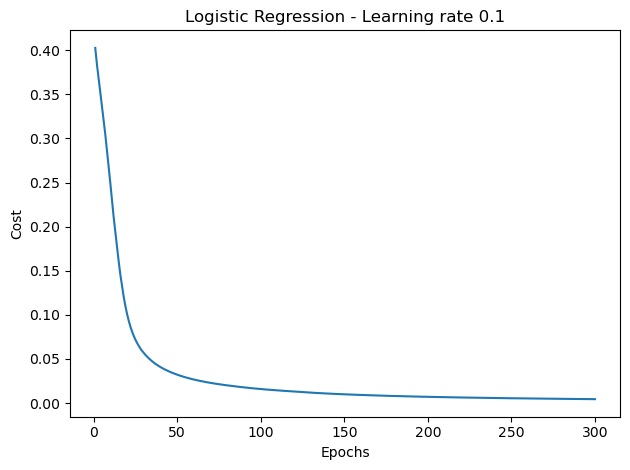

In [38]:

plt.plot(range(1, len(loss_list) + 1), loss_list)
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Logistic Regression - Learning rate 0.1')

plt.tight_layout()

In [ ]:

input_size = 4
hidden_size = 5
output_size = 1
num_epochs = 300
learning_rate = 0.1

In [42]:


class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size) 
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)  
    
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return torch.sigmoid(out)
'''
super(NeuralNet, self).__init__()
这行代码的核心目的是调用当前类（NeuralNet）的父类（nn.Module）的构造函数（__init__方法）。
super(): 这是Python的一个内置函数，用于返回一个代理对象，该对象允许你调用父类（或兄弟类）的方法。它是实现继承和正确初始化继承链的推荐方式。
(NeuralNet, self): 这是传递给 super()的两个参数，用于明确指定从哪个类（NeuralNet）开始，在方法解析顺序（MRO）列表中查找其父类，并将实例（self）与查找过程绑定。在Python 3中，在类的实例方法内，你可以直接使用更简洁的 super().__init__()，效果完全相同。
.__init__(): 这是调用父类的构造函数（__init__方法）本身。
所以，简单来说，super(NeuralNet, self).__init__()的意思就是：“执行我（NeuralNet）的父类（nn.Module）的初始化代码。” 
'''
model = NeuralNet(input_size, hidden_size, output_size)
'''这里初始化参数是在NeuralNet类的__init__()中处理'''

In [43]:
criterion = nn.BCELoss()  
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)  

In [44]:

for epoch in range(num_epochs):

    inputs = torch.tensor(X_std,dtype=torch.float)
    targets = torch.tensor(y.reshape(-1,1),dtype=torch.float)
    outputs = model(inputs)

    loss = criterion(outputs, targets)
    

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 50 == 0:
        print ('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, loss.item()))
''' model(inputs) 这里的 inputs是在NeuralNet类的__call__方法中被处理，NeuralNet没有定义该方法，
所以会去找其父类nn.Module中的__call__方法'''


Epoch [50/300], Loss: 0.1694
Epoch [100/300], Loss: 0.0365
Epoch [150/300], Loss: 0.0169
Epoch [200/300], Loss: 0.0105
Epoch [250/300], Loss: 0.0074
Epoch [300/300], Loss: 0.0057


In [45]:
import pandas as pd
df = pd.read_csv('../data/iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [46]:
X = df.iloc[:,:4].values
y = df.iloc[:,4].values

In [48]:
X_std = np.copy(X)
X_std[:,0] = (X[:,0] - X[:,0].mean()) / X[:,0].std()
X_std[:,1] = (X[:,1] - X[:,1].mean()) / X[:,1].std()
X_std[:,2] = (X[:,2] - X[:,2].mean()) / X[:,2].std()
X_std[:,3] = (X[:,3] - X[:,3].mean()) / X[:,3].std()

In [49]:
label_dict = {'Setosa':0,'Versicolor':1,'Virginica':2}

In [50]:
y = np.array([label_dict[i] for i in y])

In [51]:

input_size = 4
hidden_size = 5
output_size = 3
num_epochs = 300
learning_rate = 0.1

In [52]:
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size) 
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)  
    
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

model = NeuralNet(input_size, hidden_size, output_size)


In [53]:
criterion = nn.CrossEntropyLoss()  #交叉熵损失函数
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)  

In [54]:

for epoch in range(num_epochs):

    inputs = torch.tensor(X_std,dtype=torch.float)
    targets = torch.tensor(y,dtype=torch.long)
    outputs = model(inputs)

    loss = criterion(outputs, targets)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 50 == 0:
        print ('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, loss.item()))



Epoch [50/300], Loss: 0.4165
Epoch [100/300], Loss: 0.2940
Epoch [150/300], Loss: 0.2246
Epoch [200/300], Loss: 0.1742
Epoch [250/300], Loss: 0.1389
Epoch [300/300], Loss: 0.1154
